In [38]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [39]:
df = pd.read_csv("heart.csv")

In [40]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [41]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [42]:
df.duplicated().sum()

np.int64(723)

In [43]:
df.drop_duplicates(inplace=True)

In [44]:
def plot_kde(df):
   numeric_cols = df.select_dtypes(include='number')
   plt.figure(figsize=(20,40))
   
   for i, col in enumerate(numeric_cols):
      plt.subplot(11,4, i+ 1)
      sns.kdeplot(df[col])

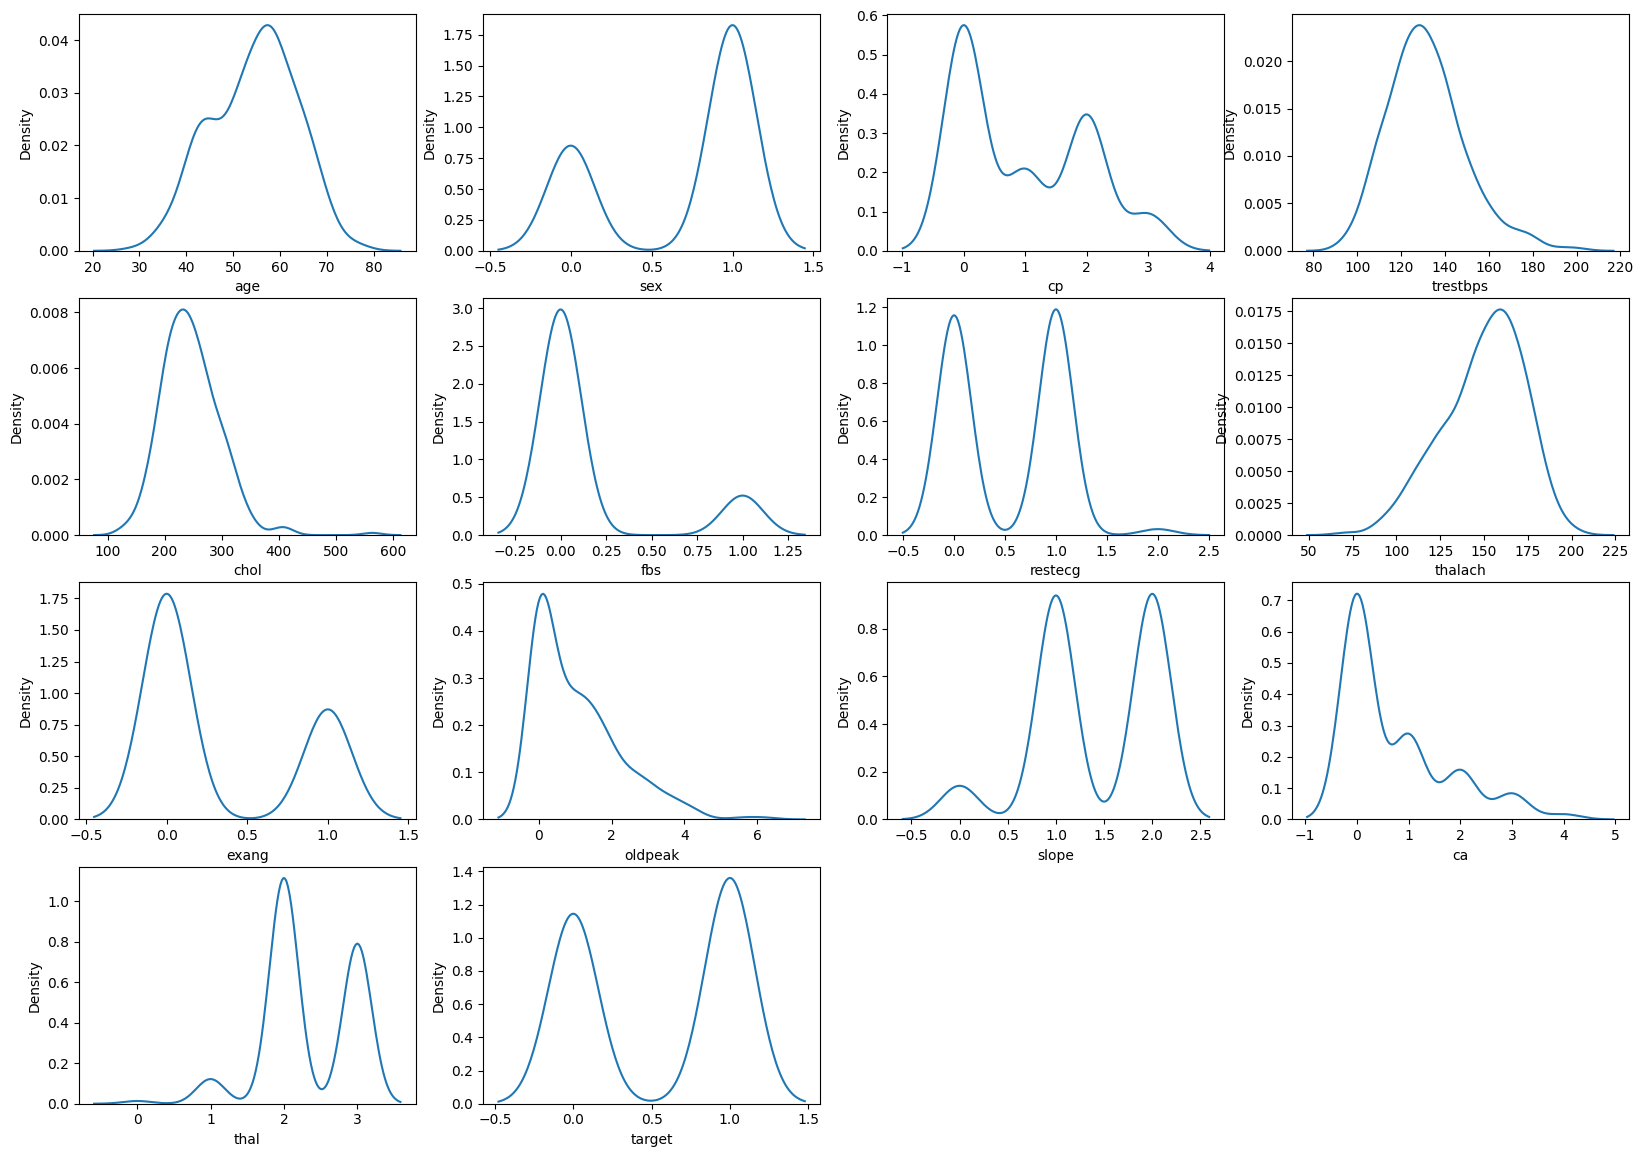

In [45]:
plot_kde(df)

In [46]:
def plot_outlier(df):
   numeric_cols = df.select_dtypes(include='number')
   plt.figure(figsize=(20,40))
   
   for i, col in enumerate(numeric_cols):
      plt.subplot(11,4, i+ 1)
      sns.boxplot(df[col])

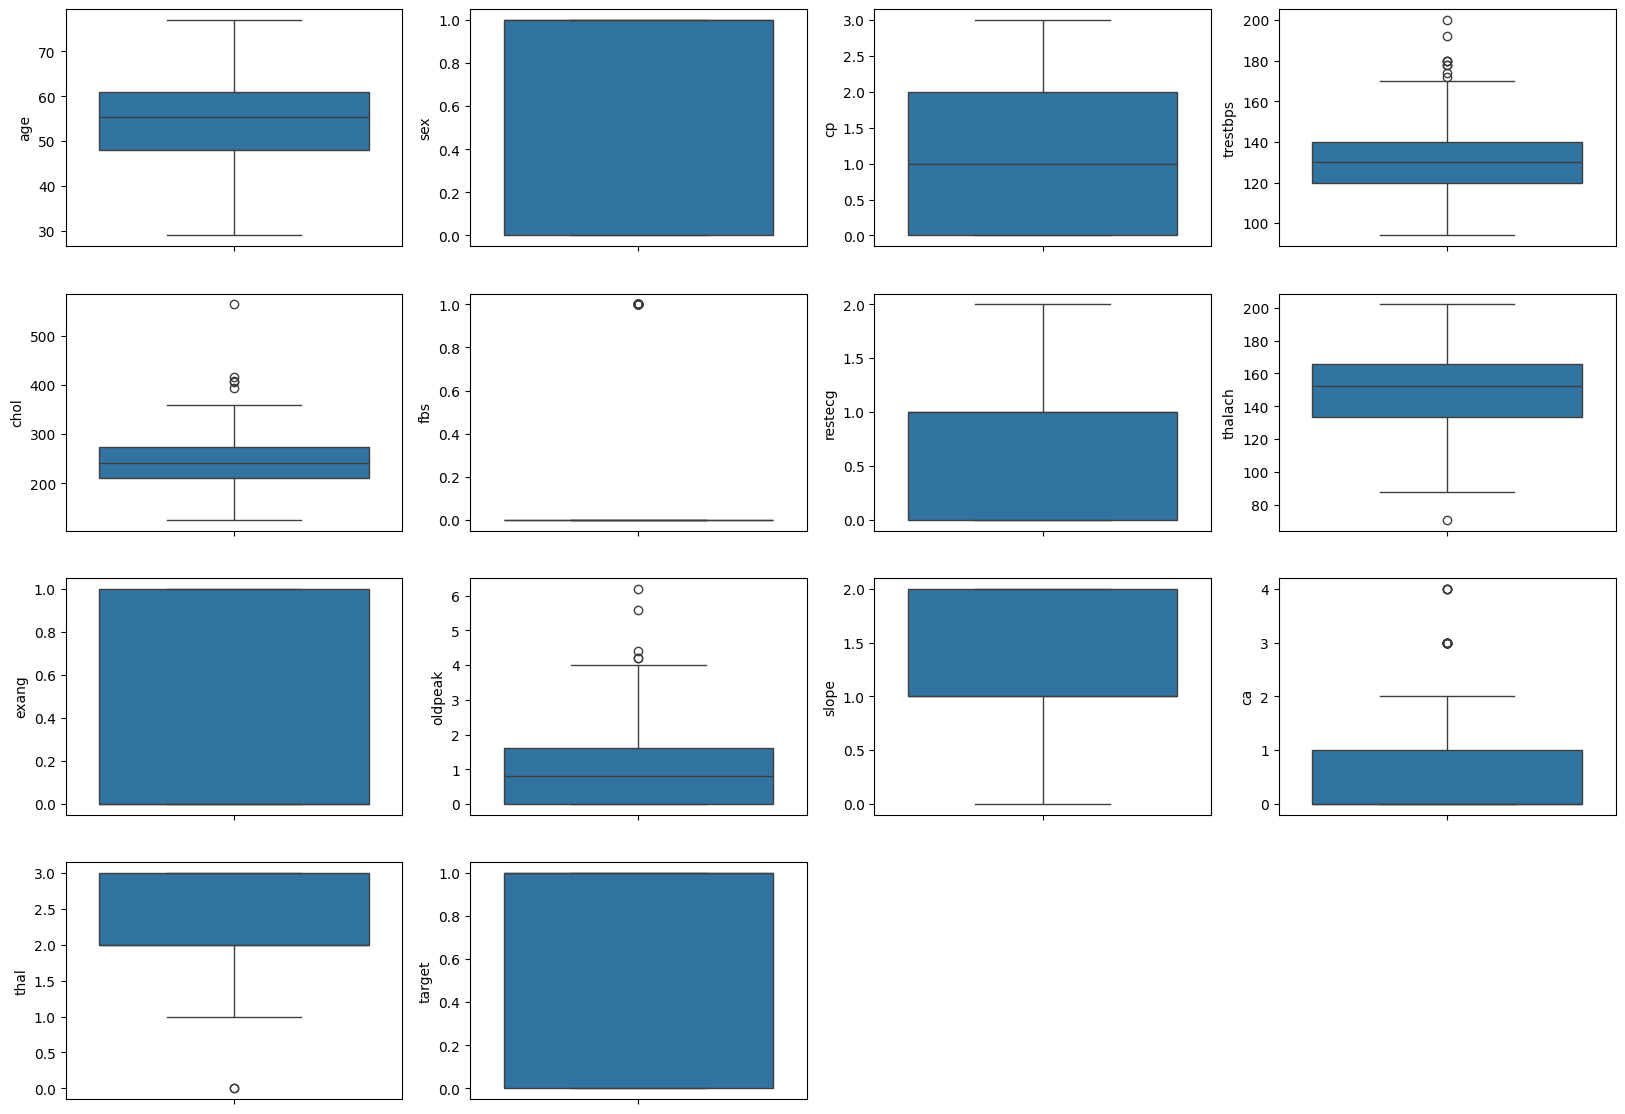

In [47]:
plot_outlier(df)

In [48]:
X = df.drop(columns='target')
y = df['target']

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline 
from sklearn.compose import ColumnTransformer 
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import classification_report, accuracy_score, roc_curve, confusion_matrix

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [51]:
num_cols = ['age',
 'sex',
 'cp',
 'trestbps',
 'chol',
 'fbs',
 'restecg',
 'thalach',
 'exang',
 'oldpeak',
 'slope',
 'ca',
 'thal',]

num_pipleine = Pipeline(steps=[
   ("scaling ", StandardScaler())
])

In [52]:
preprocess = ColumnTransformer(transformers=[
   ("num_pipline", num_pipleine, num_cols)
])

In [53]:
model = Pipeline(steps=[
   ('preprocess', preprocess),
   ('model', LogisticRegression())
])

In [54]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num_pipline',
                                                  Pipeline(steps=[('scaling ',
                                                                   StandardScaler())]),
                                                  ['age', 'sex', 'cp',
                                                   'trestbps', 'chol', 'fbs',
                                                   'restecg', 'thalach',
                                                   'exang', 'oldpeak', 'slope',
                                                   'ca', 'thal'])])),
                ('model', LogisticRegression())])

In [55]:
y_pred = model.predict(X_test)

print("Accuracy Score : ", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy Score :  0.7704918032786885
              precision    recall  f1-score   support

           0       0.88      0.66      0.75        32
           1       0.70      0.90      0.79        29

    accuracy                           0.77        61
   macro avg       0.79      0.78      0.77        61
weighted avg       0.79      0.77      0.77        61

